In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install -q pyspark findspark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# No need to download Spark—pip installation includes Spark JARs

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ColabSpark").getOrCreate()
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pyspark.sql.functions import col, when, lit, expr, coalesce
from pyspark.ml.feature import Bucketizer
import numpy as np

# -----------------------------------------------
# NEW: Define Paths
# -----------------------------------------------
BASE_DIR = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"

SRC = f"{BASE_DIR}/final_selected_table_imputed.csv"

# This will be the OUTPUT path for this construction script
OUT_PATH = f"{BASE_DIR}/final_constructed_table_spark"
OUT_PATH_CSV = f"{BASE_DIR}/final_constructed_table" # Optional CSV output path

# -----------------------------------------------
# 2. Load Data (from Google Drive)
# -----------------------------------------------
# Load imputed CSV file from the specified Google Drive path
df = spark.read.csv(SRC, header=True, inferSchema=True)

print(f"Original data loaded from {SRC}")
print(f"Shape: {df.count()} rows, {len(df.columns)} columns")

Original data loaded from /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_selected_table_imputed.csv
Shape: 25403 rows, 59 columns


In [5]:
# =========================================
# 3.3 Data Construction (PySpark version)
# Retained + new derived variables
# =========================================

from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, StringType, DoubleType

# -----------------------------------------
# 1) Age band
# -----------------------------------------
if "AGE_P" in df.columns:
    df = df.withColumn(
        "AGE_BAND",
        F.when(F.col("AGE_P") <= 29, "18-29")
         .when(F.col("AGE_P") <= 44, "30-44")
         .when(F.col("AGE_P") <= 59, "45-59")
         .otherwise("60+")
    )

# -----------------------------------------
# 2) BMI categories
# -----------------------------------------
if "BMI" in df.columns:
    df = df.withColumn(
        "BMI_CAT",
        F.when(F.col("BMI") < 18.5, "Underweight")
         .when(F.col("BMI") < 25, "Normal")
         .when(F.col("BMI") < 30, "Overweight")
         .otherwise("Obese")
    )

# -----------------------------------------
# 3) Sleep sufficiency
# -----------------------------------------
if "ASISLEEP" in df.columns:
    df = df.withColumn(
        "SLEEP_SUFFICIENT",
        F.when((F.col("ASISLEEP") >= 7) & (F.col("ASISLEEP") <= 9), 1).otherwise(0)
    )
    df = df.withColumn(
        "SLEEP_SUFF_LABEL",
        F.when(F.col("SLEEP_SUFFICIENT") == 1, "Sufficient")
         .otherwise("Insufficient")
    )

# -----------------------------------------
# 4) Mental Health Score (reverse-coded sum)
# -----------------------------------------
mdi_items = ["ASISAD","ASINERV","ASIRSTLS","ASIHOPLS","ASIEFFRT","ASIWTHLS"]
mdi_present = [c for c in mdi_items if c in df.columns]

if mdi_present:
    def reverse_minmax(colname):
        """ (min + max) - value"""
        lo = df.agg(F.min(colname)).first()[0]
        hi = df.agg(F.max(colname)).first()[0]
        return (lo + hi) - F.col(colname)

    for c in mdi_present:
        df = df.withColumn(c + "_REV", reverse_minmax(c))

    rev_cols = [c + "_REV" for c in mdi_present]
    df = df.withColumn("MENTAL_HEALTH_SCORE", sum(F.col(c) for c in rev_cols))

# -----------------------------------------
# 5) Alcohol consumption intensity bands
# -----------------------------------------
if "ALC12MYR" in df.columns:
    df = df.withColumn(
        "ALC_DAYS_CAT",
        F.when(F.col("ALC12MYR") == 0, "0")
         .when(F.col("ALC12MYR") <= 12, "1-12")
         .when(F.col("ALC12MYR") <= 52, "13-52")
         .when(F.col("ALC12MYR") <= 156, "53-156")
         .otherwise("157+")
    )

# -----------------------------------------
# 6) Work exposure buckets
# -----------------------------------------
if "YRSWRKPA" in df.columns:
    df = df.withColumn(
        "WORK_EXP_CAT",
        F.when(F.col("YRSWRKPA") <= 5, "0-5")
         .when(F.col("YRSWRKPA") <= 15, "6-15")
         .when(F.col("YRSWRKPA") <= 25, "16-25")
         .otherwise("26+")
    )

# -----------------------------------------
# 7) Pain index (frequency × intensity)
# -----------------------------------------
if {"PAIN_2A","PAIN_4"}.issubset(df.columns):
    pain_freq_map = {1: 0, 2: 1, 3: 2, 4: 3}
    pain_int_map  = {1: 1, 3: 2, 2: 3}
    mapping_freq = F.create_map([F.lit(x) for x in sum(pain_freq_map.items(), ())])
    mapping_int  = F.create_map([F.lit(x) for x in sum(pain_int_map.items(), ())])

    df = df.withColumn("PAIN_FREQ", mapping_freq.getItem(F.col("PAIN_2A")))
    df = df.withColumn("PAIN_INT",  mapping_int.getItem(F.col("PAIN_4")))
    df = df.withColumn("PAIN_INDEX", (F.col("PAIN_FREQ") * F.col("PAIN_INT")).cast(DoubleType()))

# -----------------------------------------
# 8) Sleep × Work interaction
# -----------------------------------------
if {"ASISLEEP","DOINGLWA"}.issubset(df.columns):
    df = df.withColumn("SLEEP_X_WORK", F.col("ASISLEEP") * F.col("DOINGLWA"))

# -----------------------------------------
# 9) Chronic disease count
# -----------------------------------------
chronic_vars = ["HYPEV","CHDEV","HRTEV","CANEV","MIEV","DIBPRE2"]
present_chronic = [c for c in chronic_vars if c in df.columns]
for c in present_chronic:
    df = df.withColumn(c + "_Y", F.when(F.col(c) == 1, 1).otherwise(0))
if present_chronic:
    df = df.withColumn("CHRONIC_COUNT", sum(F.col(c + "_Y") for c in present_chronic).cast(IntegerType()))

# -----------------------------------------
# 10) Economic/accessibility barriers & utilization
# -----------------------------------------
# 10.1 Cannot afford medical/dental care
if {"AHCAFYR1","AHCAFYR3"}.issubset(df.columns):
    df = df.withColumn(
        "AFFORD_ANY",
        F.when((F.col("AHCAFYR1") == 1) | (F.col("AHCAFYR3") == 1), 1).otherwise(0)
    )

# 10.2 Office visit categories
if "AHCNOYR2" in df.columns:
    df = df.withColumn(
        "OFFICE_VISITS_CAT",
        F.when(F.col("AHCNOYR2") == 0, "0")
         .when(F.col("AHCNOYR2") == 1, "1")
         .when(F.col("AHCNOYR2").isin(2,3), "2-3")
         .when(F.col("AHCNOYR2").isin(4,5), "4-5")
         .when(F.col("AHCNOYR2").isin(6,7), "6-7")
         .otherwise("8+")
    )

# 10.3 Any ER visit in past year
if "AHERNOY2" in df.columns:
    df = df.withColumn("ER_VISIT_ANY", F.when(F.col("AHERNOY2") > 0, 1).otherwise(0))

# -----------------------------------------
# Final check
# -----------------------------------------
print(f"✅ Constructed dataset: {df.count()} rows, {len(df.columns)} columns")
print("✅ Key derived columns:",
      [c for c in ["AGE_BAND","BMI_CAT","SLEEP_SUFFICIENT","MENTAL_HEALTH_SCORE",
                   "ALC_DAYS_CAT","WORK_EXP_CAT","PAIN_INDEX","SLEEP_X_WORK",
                   "CHRONIC_COUNT","AFFORD_ANY","OFFICE_VISITS_CAT","ER_VISIT_ANY"]
       if c in df.columns])

/usr/local/lib/python3.12/dist-packages/pyspark/sql/column.py:460: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


✅ Constructed dataset: 25403 rows, 85 columns
✅ Key derived columns: ['AGE_BAND', 'BMI_CAT', 'SLEEP_SUFFICIENT', 'MENTAL_HEALTH_SCORE', 'WORK_EXP_CAT', 'PAIN_INDEX', 'SLEEP_X_WORK', 'CHRONIC_COUNT', 'AFFORD_ANY', 'OFFICE_VISITS_CAT', 'ER_VISIT_ANY']


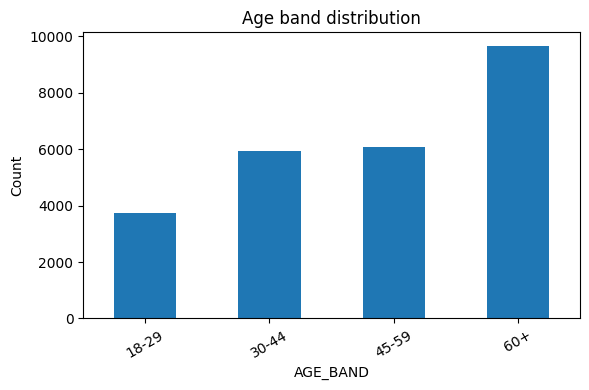

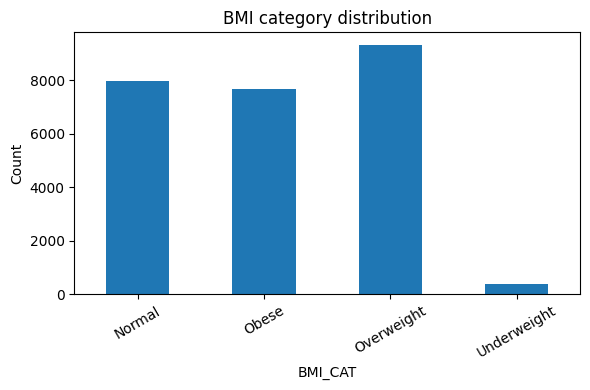

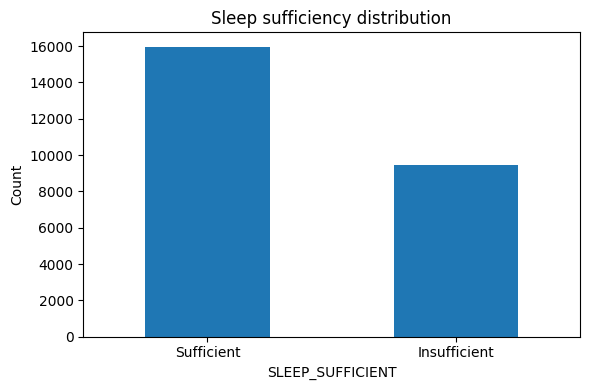

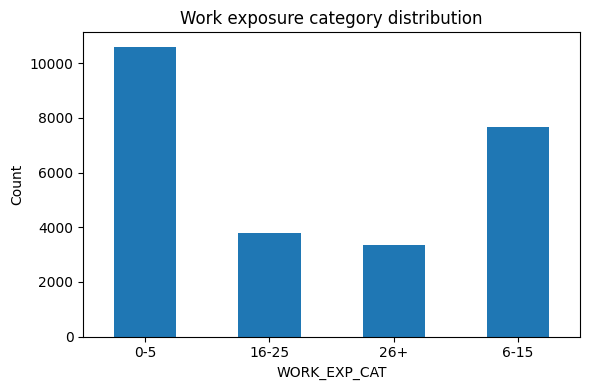

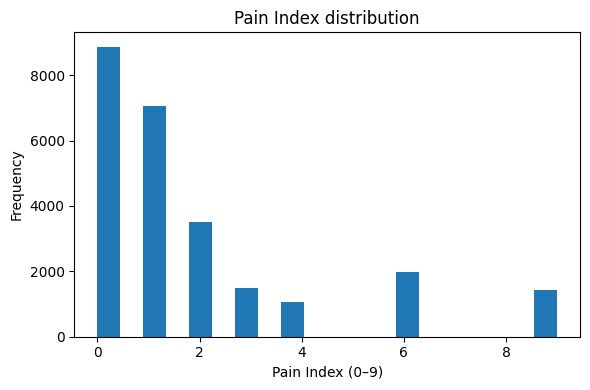

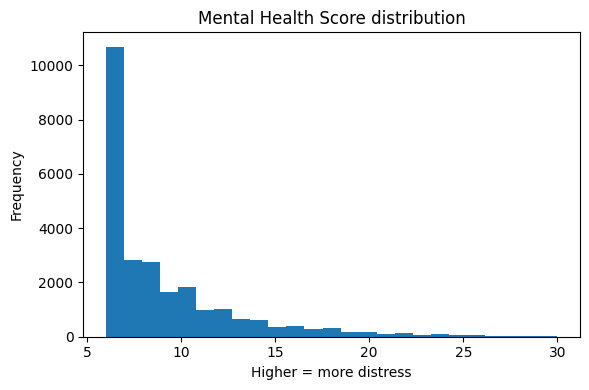

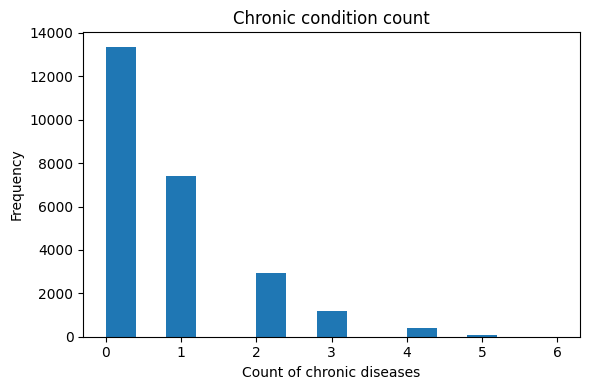

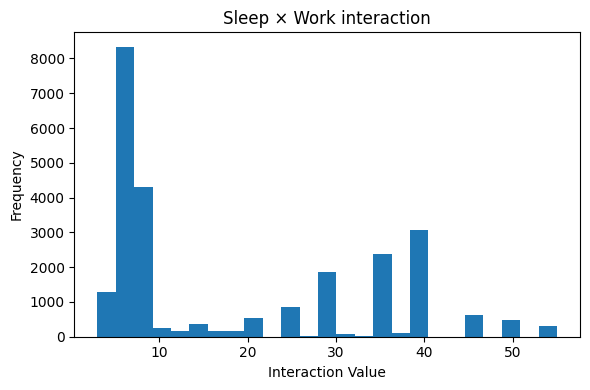

✅ All feature plots generated and displayed.
Figures saved under: /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs


In [9]:
# =========================================
# 3.3.1 Visualization of Constructed Features
# =========================================
import matplotlib.pyplot as plt
import pandas as pd

# Collect to pandas for visualization
plot_cols = [
    "AGE_BAND", "BMI_CAT", "SLEEP_SUFFICIENT", "ALC_INTENSITY", "WORK_EXP_CAT",
    "PAIN_INDEX", "MENTAL_HEALTH_SCORE", "CHRONIC_COUNT",
    "ACCESS_BARRIER_COUNT", "UTILIZATION_SCORE", "SLEEP_X_WORK"
]
plot_df = df.select([c for c in plot_cols if c in df.columns]).toPandas()

FIG_DIR = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs"

# Helper function
def show_and_save(fig_name, title, plot_func):
    plt.figure(figsize=(6,4))
    plot_func()
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{FIG_DIR}/{fig_name}.png", dpi=200)
    plt.close()

# ---------- Demographics ----------
if "AGE_BAND" in plot_df:
    show_and_save("fig_3_3_age_band", "Age band distribution",
        lambda: plot_df["AGE_BAND"].value_counts().sort_index().plot(kind="bar", rot=30, ylabel="Count"))

if "BMI_CAT" in plot_df:
    show_and_save("fig_3_3_bmi_cat", "BMI category distribution",
        lambda: plot_df["BMI_CAT"].value_counts().sort_index().plot(kind="bar", rot=30, ylabel="Count"))

# ---------- Behavioral/Lifestyle ----------
if "SLEEP_SUFFICIENT" in plot_df:
    labels = {1: "Sufficient", 0: "Insufficient"}
    tmp = plot_df["SLEEP_SUFFICIENT"].map(labels)
    show_and_save("fig_3_3_sleep_suff", "Sleep sufficiency distribution",
        lambda: tmp.value_counts().reindex(["Sufficient", "Insufficient"]).plot(kind="bar", rot=0, ylabel="Count"))

if "ALC_INTENSITY" in plot_df:
    show_and_save("fig_3_3_alc_intensity", "Alcohol intensity distribution",
        lambda: plot_df["ALC_INTENSITY"].dropna().plot(kind="hist", bins=25, xlabel="Intensity"))

if "WORK_EXP_CAT" in plot_df:
    show_and_save("fig_3_3_work_exp", "Work exposure category distribution",
        lambda: plot_df["WORK_EXP_CAT"].value_counts().sort_index().plot(kind="bar", rot=0, ylabel="Count"))

# ---------- Composite Health Indicators ----------
if "PAIN_INDEX" in plot_df:
    show_and_save("fig_3_3_pain_index", "Pain Index distribution",
        lambda: plot_df["PAIN_INDEX"].dropna().plot(kind="hist", bins=20, xlabel="Pain Index (0–9)"))

if "MENTAL_HEALTH_SCORE" in plot_df:
    show_and_save("fig_3_3_mental_health", "Mental Health Score distribution",
        lambda: plot_df["MENTAL_HEALTH_SCORE"].dropna().plot(kind="hist", bins=25, xlabel="Higher = more distress"))

if "CHRONIC_COUNT" in plot_df:
    show_and_save("fig_3_3_chronic", "Chronic condition count",
        lambda: plot_df["CHRONIC_COUNT"].dropna().plot(kind="hist", bins=15, xlabel="Count of chronic diseases"))

# ---------- Access & Utilization ----------
if "ACCESS_BARRIER_COUNT" in plot_df:
    show_and_save("fig_3_3_access_barrier", "Economic / Access barrier count",
        lambda: plot_df["ACCESS_BARRIER_COUNT"].dropna().plot(kind="hist", bins=10, xlabel="Barrier Count"))

if "UTILIZATION_SCORE" in plot_df:
    show_and_save("fig_3_3_utilization", "Healthcare utilization score",
        lambda: plot_df["UTILIZATION_SCORE"].dropna().plot(kind="hist", bins=10, xlabel="Utilization Level"))

# ---------- Interaction ----------
if "SLEEP_X_WORK" in plot_df:
    show_and_save("fig_3_3_sleep_x_work", "Sleep × Work interaction",
        lambda: plot_df["SLEEP_X_WORK"].dropna().plot(kind="hist", bins=25, xlabel="Interaction Value"))

print("✅ All feature plots generated and displayed.")
print(f"Figures saved under: {FIG_DIR}")

In [6]:
output_path = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_constructed_table.csv"

df.coalesce(1).write \
    .option("header", True) \
    .mode("overwrite") \
    .csv(output_path)

print(f"✅ Saved final modeling table to: {output_path}")

✅ Saved final modeling table to: /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_constructed_table.csv


In [7]:
output_path = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_constructed_table.parquet"

df.write.mode("overwrite").parquet(output_path)

print(f"✅ Saved final modeling table to: {output_path}")

✅ Saved final modeling table to: /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_constructed_table.parquet
